# Biological PIN and AN heat maps

Dieses Notebook untersucht ausschließlich die biologisch trainierten GAIL-Policies. Für jede Interaktionsrichtung werden die separat auf 16 beziehungsweise 32 Prey trainierten Modelle in einem 2×2-Grid verglichen. Die Zeilen entsprechen der Gruppengröße; die Spalten zeigen PIN und AN. Gruppengrößen und Achsenbeschriftungen stehen direkt an jedem Panel. Eine vertikale Farbskala rechts neben jeder Karte weist die dargestellten PIN-Werte in Grad beziehungsweise die normalisierte Attention aus.

In [1]:
from pathlib import Path
import importlib, os, sys
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ANALYSIS_DIR = Path.cwd().resolve()
if ANALYSIS_DIR.name != 'Paper Analysis':
    ANALYSIS_DIR = ANALYSIS_DIR / 'Paper Analysis'
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))
import heat_maps as hm
hm = importlib.reload(hm)

GRID_SIZE = int(os.getenv('HEAT_MAP_GRID_SIZE', '100'))
N_ORIENTATIONS = int(os.getenv('HEAT_MAP_ORIENTATIONS', '100'))
BATCH_SIZE = int(os.getenv('HEAT_MAP_BATCH_SIZE', '65536'))
DEVICE = os.getenv('HEAT_MAP_DEVICE', 'cpu')
PIN_SMOOTHING_SIGMA = float(os.getenv('HEAT_MAP_PIN_SMOOTHING_SIGMA', '2.5'))
SAVE_ARTIFACTS = os.getenv('HEAT_MAP_SAVE_ARTIFACTS', '0') == '1'
OUTPUT_DIR = ANALYSIS_DIR / os.getenv('HEAT_MAP_OUTPUT_DIR', 'heat_map_outputs')
assert GRID_SIZE >= 2 and N_ORIENTATIONS >= 1 and BATCH_SIZE >= 1
display({'grid_size': GRID_SIZE, 'orientations': N_ORIENTATIONS,
         'pin_smoothing_sigma_cells': PIN_SMOOTHING_SIGMA,
         'device': DEVICE, 'save_artifacts': SAVE_ARTIFACTS})

{'grid_size': 100,
 'orientations': 100,
 'pin_smoothing_sigma_cells': 2.5,
 'device': 'cpu',
 'save_artifacts': False}

## Gemeinsame Auswertungslogik

Die Karten verwenden das etablierte relative Positionsraster von −1 bis +1 auf beiden Achsen und mitteln pro Rasterpunkt über gleichmäßig verteilte relative Bewegungsrichtungen. Für N=16 und N=32 werden die jeweiligen `16only`- und `32only`-Checkpoints geladen. Dadurch repräsentieren die beiden Zeilen tatsächlich gruppenspezifisch trainierte biologische Modelle.

PIN zeigt den Erwartungswert der tatsächlich ausgeführten stochastischen Policy: `E[2·sigmoid(mu + sigma·epsilon)−1]`. Dieser Erwartungswert wird deterministisch mit einer 12-Punkt-Gauß-Hermite-Quadratur berechnet. Die frühere Auswertung mit `tanh(mu)` war steiler als die Simulatorabbildung und ignorierte die gelernte Aktionsvarianz. Anschließend wird ausschließlich PIN mit einem kleinen Gauß-Kernel von standardmäßig 2,5 Rasterzellen geglättet (bei 100×100 Punkten etwa 0,051 relative Positionseinheiten). Diese Glättung reduziert lokale ReLU-/Rasterartefakte; die ungeglätteten Werte bleiben für den Audit erhalten. AN ist bereits glatt und wird nicht nachbearbeitet.

PIN behält die `inferno`-Farbskala und zeigt den vorzeichenbehafteten Drehbeitrag in Grad auf einer symmetrischen Skala um null. AN behält `RdBu` und zeigt die normalisierte Attention im festen Bereich von 0 bis 1. Innerhalb jeder Abbildung verwenden N=16 und N=32 dieselben Wertebereiche und Farbnormalisierungen.

In [2]:
manifest = hm.checkpoint_manifest()
if not manifest['available'].all():
    raise FileNotFoundError('At least one biological group-specific checkpoint is missing')
display(manifest[['n_prey', 'training_run', 'policy_role', 'available', 'bytes']])
biological_maps = hm.compute_biological_heat_maps(
    grid_size=GRID_SIZE, n_orientations=N_ORIENTATIONS,
    batch_size=BATCH_SIZE, device=DEVICE,
    pin_smoothing_sigma=PIN_SMOOTHING_SIGMA)
display(Markdown('### Methodischer Varianten-Audit'))
display(hm.action_link_diagnostics(biological_maps).round(4))
display(hm.smoothing_variant_diagnostics(biological_maps).round(4))

,n_prey,training_run,policy_role,available,bytes
0,16,stage1_seed42_16only,predator,True,92250
1,16,stage1_seed42_16only,prey,True,93274
2,32,stage1_seed42_32only,predator,True,92250
3,32,stage1_seed42_32only,prey,True,93274


### Methodischer Varianten-Audit

,n_prey,interaction,legacy_vs_policy_median_correlation,legacy_normalized_roughness,policy_normalized_roughness,stochastic_mean_correlation,stochastic_mean_normalized_roughness
0,16,predator_prey,0.9979,0.0066,0.0062,0.9999,0.0061
1,16,prey_predator,0.9798,0.0084,0.0075,0.9992,0.0074
2,16,prey_prey,0.9987,0.0073,0.0070,0.9999,0.0070
3,32,predator_prey,0.9952,0.0088,0.0084,0.9996,0.0084
4,32,prey_predator,0.9963,0.0065,0.0061,0.9998,0.0060
5,32,prey_prey,0.9974,0.0069,0.0064,0.9998,0.0063


,sigma_cells,sigma_position,mean_roughness_ratio,max_normalized_RMSE,min_correlation
0,0.00,0.0000,1.0000,0.0000,1.0000
1,0.75,0.0152,0.9891,0.0010,1.0000
2,1.50,0.0303,0.9704,0.0031,0.9999
3,2.50,0.0505,0.9416,0.0069,0.9994


## Predator → Prey

Der Predator ist das fokale Tier im Ursprung. Die PIN-Karte zeigt, welchen links- beziehungsweise rechtsgerichteten Drehbeitrag ein Prey an der jeweiligen relativen Position auslöst. Die AN-Karte zeigt, welche Prey-Positionen das Predator-Modell stärker gewichtet. Oben steht das auf N=16 trainierte Modell, unten das auf N=32 trainierte Modell.

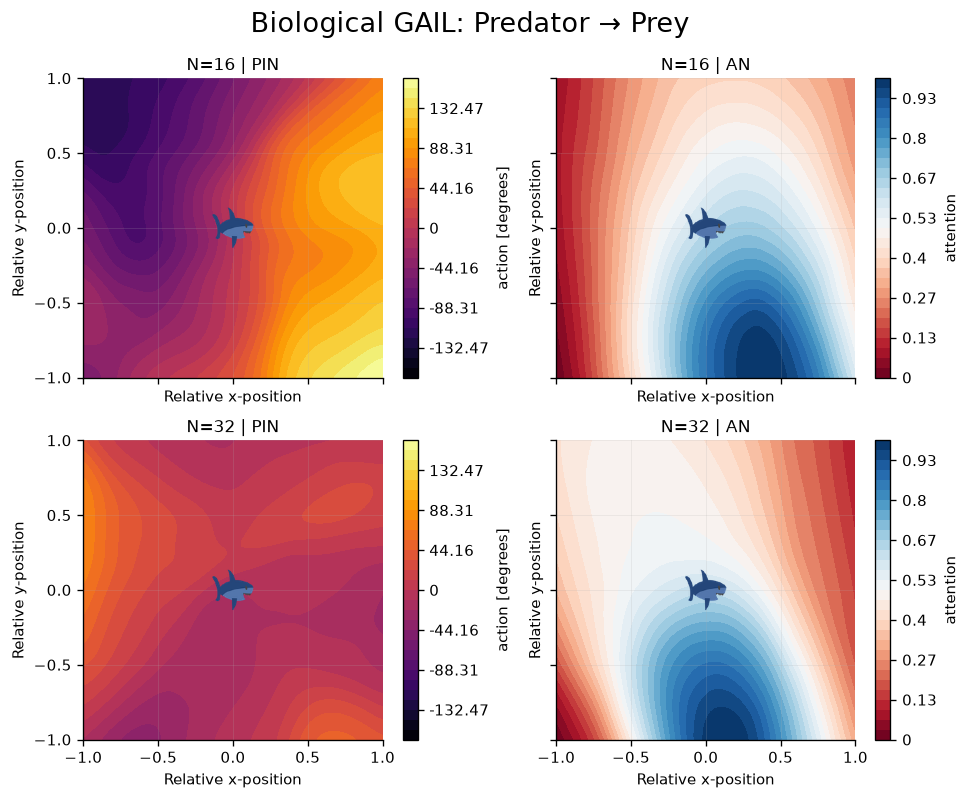

In [3]:
fig = hm.plot_interaction_grid(biological_maps, 'predator_prey')
display(fig)
plt.close(fig)

## Prey → Predator

Das Prey ist das fokale Tier im Ursprung und der Nachbar wird über das Predator-Flag als Predator gekennzeichnet. Damit zeigt das Grid ausschließlich die gelernte Bedrohungsinteraktion: PIN beschreibt den Drehbeitrag des Predators, AN dessen relative Gewichtung.

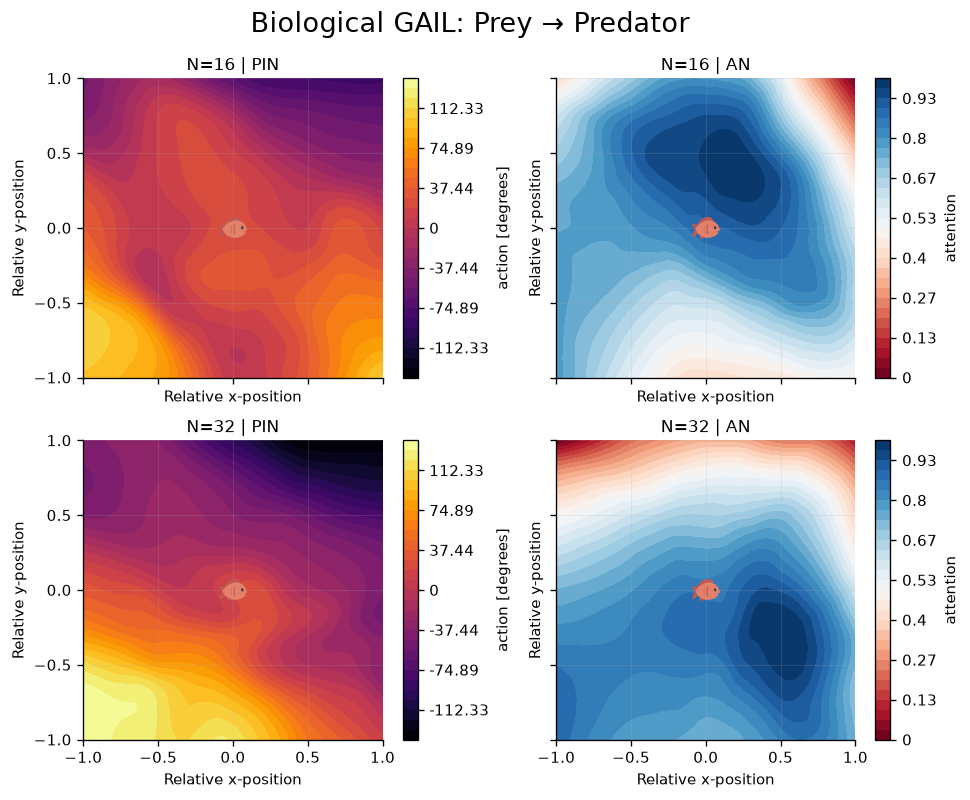

In [4]:
fig = hm.plot_interaction_grid(biological_maps, 'prey_predator')
display(fig)
plt.close(fig)

## Prey → Prey

Das Prey ist erneut das fokale Tier, der Nachbar wird nun als anderes Prey gekennzeichnet. Diese Karten isolieren deshalb die soziale Prey–Prey-Regel von der Predator-Reaktion und erlauben den direkten Vergleich der bei N=16 und N=32 gelernten Interaktionsstruktur.

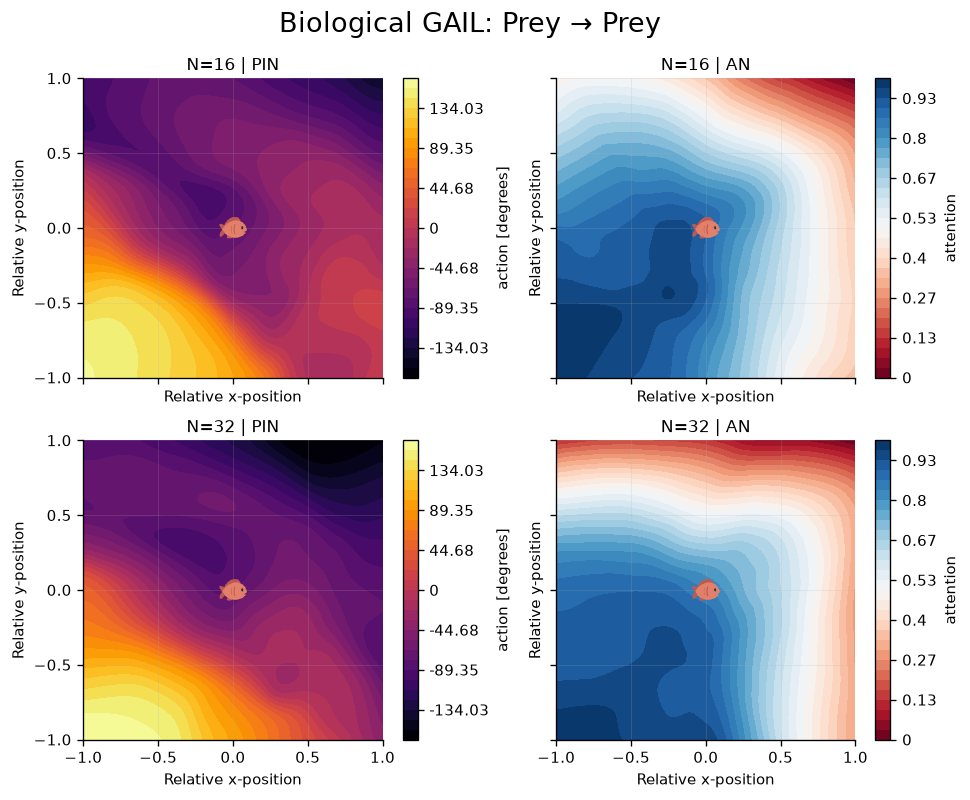

In [5]:
fig = hm.plot_interaction_grid(biological_maps, 'prey_prey')
display(fig)
plt.close(fig)

if SAVE_ARTIFACTS:
    saved_paths = hm.save_heat_map_artifacts(biological_maps, OUTPUT_DIR)
    display(Markdown('Gespeicherte Heat-Map-Artefakte:\n\n' +
                     '\n'.join(f'- `{path}`' for path in saved_paths)))